In [ ]:
# Adding LLM as an agent for understanding the user query and calling the tool
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,   # explicit dtype (faster + smaller than "auto"/float32)
    device_map="auto",
    attn_implementation="sdpa",  # faster attention kernel, no extra install needed
)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
from langchain_core.tools import tool
import json
# include all the three tools


In [ ]:
# 1. weather tool - now using a real-time weather API (Open-Meteo, free, no API key needed)
import requests

@tool
def weather(city: str):
  """Returns the current real-time weather for a given city."""
  try:
    # step 1: turn the city name into latitude/longitude
    geo_url = "https://geocoding-api.open-meteo.com/v1/search"
    geo_res = requests.get(geo_url, params={"name": city, "count": 1}).json()
    if not geo_res.get("results"):
      return "weather data not found"

    lat = geo_res["results"][0]["latitude"]
    lon = geo_res["results"][0]["longitude"]

    # step 2: fetch the current weather for that location
    weather_url = "https://api.open-meteo.com/v1/forecast"
    weather_res = requests.get(weather_url, params={
        "latitude": lat,
        "longitude": lon,
        "current_weather": True
    }).json()

    current = weather_res.get("current_weather", {})
    temp = current.get("temperature")
    wind = current.get("windspeed")
    return f"{temp}C, wind {wind} km/h"
  except Exception as e:
    return f"weather data not found: {e}"


In [ ]:
# City info tool - now pulling a real summary from Wikipedia instead of a hardcoded dict
@tool
def Cityinfo(city: str):
  """Returns real city information for a given city, pulled from Wikipedia."""
  try:
    url = "https://en.wikipedia.org/api/rest_v1/page/summary/" + city.strip().replace(" ", "_")
    headers = {"User-Agent": "MyTravelAgent/1.0 (myemail@example.com)"}
    res = requests.get(url, headers=headers)
    if res.status_code != 200:
      return "city info data not found"

    data = res.json()
    return data.get("extract", "city info data not found")
  except Exception as e:
    return f"city info data not found: {e}"


In [ ]:
# Currency exchange tool - now using a real-time free API (frankfurter.app, backed by the European Central Bank)
@tool
def currency(amount: float, from_currency: str, to_currency: str):
  """Convert the amount from one currency to another using live exchange rates."""
  try:
    url = "https://api.frankfurter.app/latest"
    res = requests.get(url, params={"from": from_currency, "to": to_currency})
    if res.status_code != 200:
      return "Conversion not available"

    data = res.json()
    rate = data.get("rates", {}).get(to_currency)
    if rate is None:
      return "Conversion not available"

    return amount * rate
  except Exception as e:
    return f"Conversion not available: {e}"


In [ ]:
# store all the tools in a list (useful if you later want to bind
# them straight to an LLM, e.g. model.bind_tools(tool_list))
tool_list = [weather, Cityinfo, currency]


In [ ]:
# cross check an example
print(weather.invoke({"city":"Udaipur"}))
print(Cityinfo.invoke({"city":"Udaipur"}))
print(currency.invoke({"amount":100, "from_currency":"USD", "to_currency":"INR"}))

30.4C, wind 10.0 km/h
Udaipur is a city in the north-western Indian state of Rajasthan, about 415 km (258 mi) south of the state capital Jaipur. It serves as the administrative headquarters of Udaipur district. It is the historic capital of the kingdom of Mewar in the former Rajputana Agency. It was founded in 1559 by Udai Singh II of the Sisodia clan of Rajputs, when he shifted his capital from the city of Chittorgarh to Udaipur after Chittorgarh was besieged by Akbar. It remained as the capital city till 1818 when Mewar became a British princely state, and thereafter the Mewar province became a part of Rajasthan when India gained independence in 1947. It is also known as the City of Lakes, as it is surrounded by five major artificial lakes.
9495.0


In [ ]:
# tools store to dictionary
tools={"weather": weather, "Cityinfo": Cityinfo, "currency": currency}#


In [ ]:
# langchain library installation
!pip install -q langchain langchain-huggingface

In [ ]:
# langchain library installation
!pip install -q langchain-core langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.2 MB/s eta 0:00:00


In [ ]:
import os

In [ ]:
# from langchain_huggingface import HuggingFacePipeline,ChatHuggingFace
from langchain_groq import ChatGroq
import os

os.environ["GROQ_API_KEY"] = "YOUR_GROQ_API_KEY_HERE"

# Updated to a stable Groq model name to resolve the 404 error
chat_model = ChatGroq(
    model_name="openai/gpt-oss-120b", temperature = 0.1
)

In [ ]:
# bind the tools
tools_list = [weather, Cityinfo, currency]
llm_with_tools = chat_model.bind_tools(tools_list)

In [ ]:
# now lang graph architecture
from langgraph.graph import StateGraph , MessagesState , START , END
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
from langgraph.graph import MessagesState

def agent_node(state: MessagesState):
    # For Groq, we simply invoke the model with the current messages state.
    # Groq handles the tool call/response sequence natively.
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [ ]:
tool_node = ToolNode(tools_list)

In [ ]:
graph = StateGraph(MessagesState)
graph.add_node("agent",agent_node)
graph.add_node("tools",tool_node)
graph.add_edge(START,"agent")
graph.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",  # If tools_condition returns "tools", go to the "tools" node
        "__end__": END     # If tools_condition returns "__end__", go to the END state
    }
)
graph.add_edge("tools","agent")
# Removed: graph.add_edge("agent",END) as it's handled by conditional edges
travel_agent = graph.compile()

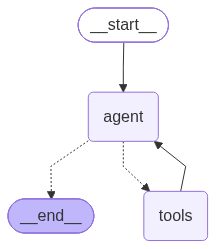

In [ ]:
from IPython.display import Image, display
display(Image(travel_agent.get_graph().draw_mermaid_png()))

In [ ]:
# invoke responses
from langchain_core.messages import HumanMessage, SystemMessage
system_msg = SystemMessage(content="""you area travel agent. use available tools
which are required to answer the user's question""")
def run_travel_agent(prompt):
  result = travel_agent.invoke({"messages":[system_msg,HumanMessage(content=prompt)]})
  return result["messages"][-1].content


In [ ]:
run_travel_agent("how is weather in Bangalore")

'The current weather in\u202fBangalore is about **29.8\u202f°C** with a wind speed of **14.6\u202fkm/h**.'

In [ ]:
result = travel_agent.invoke({"messages":[system_msg,HumanMessage(content="how is weather in Bangalore")]})
for msg in result["messages"]:
  print(type(msg), msg.content)

<class 'langchain_core.messages.system.SystemMessage'> you area travel agent. use available tools
which are required to answer the user's question
<class 'langchain_core.messages.human.HumanMessage'> how is weather in Bangalore
<class 'langchain_core.messages.ai.AIMessage'> 
<class 'langchain_core.messages.tool.ToolMessage'> 29.8C, wind 14.6 km/h
<class 'langchain_core.messages.ai.AIMessage'> The current weather in Bangalore is pleasant and warm, with a temperature of **29.8 °C** and a gentle breeze blowing at about **14.6 km/h**. It’s a good day for outdoor activities, though you might want to stay hydrated if you’re out in the sun.
